In [4]:
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd
import matplotlib.pyplot as plt

# P u l l a l l g a m e s f o r t h e 2 0 2 3 - 2 4 r e g u l a r season
games = leaguegamefinder.LeagueGameFinder(season_nullable='2024-25', season_type_nullable='Regular Season')
df: pd.DataFrame = games.get_data_frames()[0]
print(df.columns)
df.to_csv('season_raw.csv' ,index=False)

Index(['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID',
       'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT',
       'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB',
       'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS'],
      dtype='str')


In [5]:
# Keep Only columns that you need
team_stats = df[['TEAM_ABBREVIATION', 'WL', 'PTS', 'FG3M']]
team_stats.to_csv('season_breakdown.csv', index=False)

In [6]:
summary = (
    team_stats.groupby('TEAM_ABBREVIATION')
    .agg(
        games=('WL', 'count'),
        wins=('WL', lambda s: (s=='W').sum()),
        points=('PTS', 'mean'),
        threes=('FG3M', 'sum') 
    )
).reset_index()

In [9]:
summary.to_csv('season_agg.csv', index=False)

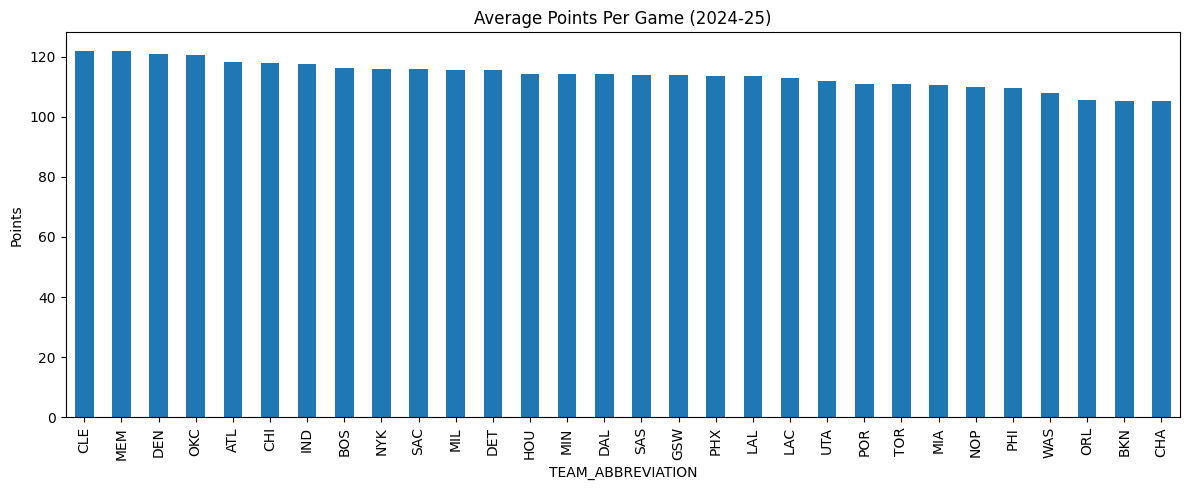

In [13]:
summary.sort_values('points', ascending=False).plot(
    x='TEAM_ABBREVIATION', y='points', kind='bar',
    legend=False, figsize=(12,5), title='Average Points Per Game (2024-25)'
)
plt.ylabel('Points')
plt.tight_layout()
plt.savefig('Avg_Points.png')
plt.show()